# Simulation Data Quality Check
physical correctness of all MRST training simulations before building the ROM.  

Checks performed:
1. all expected cases present, no failed runs
2. all `.mat` files loadable, correct array dimensions
3. no NaN/Inf, physically plausible range
4. monotone drawdown, correct rate steps, no unphysical spikes
5. Bourdet derivative, WBS unit slope, flat MTR, rising BDF
6. all three regimes captured for each (k, S) pair
7. BHP and dp-prime scale correctly with k and S
8. injected rate matches intended schedule
9. pressure drawdown cone centred on well cell

---
## 0. Imports and Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from pathlib import Path

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── Paths ─────────────────────────────────────────────────────────────────
# Adjust TRAINING_DIR to match your folder structure
TRAINING_DIR = Path('../data/01_training')       # folder containing all case subfolders
MANIFEST     = TRAINING_DIR / 'manifest.csv'

# Fixed physical constants (must match MATLAB scripts)
NX, NY       = 50, 50
N_CELLS      = NX * NY          # 2500
N_STEPS      = 350
P_INIT_PSIA  = 4500.0
WELL_CELL_PY = (round(NY/2) - 1) * NX + round(NX/2) - 1   # 0-indexed Python equivalent of MATLAB wc

print(f'Training directory : {TRAINING_DIR.resolve()}')
print(f'Manifest           : {MANIFEST}')
print(f'Expected grid      : {NX}×{NY} = {N_CELLS} cells')
print(f'Expected timesteps : {N_STEPS}')
print(f'Well cell (0-idx)  : {WELL_CELL_PY}')

Training directory : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
Manifest           : ..\data\01_training\manifest.csv
Expected grid      : 50×50 = 2500 cells
Expected timesteps : 350
Well cell (0-idx)  : 1224


---
## 1. All expected cases present - no failed run. 

In [2]:
# ── Load manifest ─────────────────────────────────────────────────────────
assert MANIFEST.exists(), f'Manifest not found at {MANIFEST}'
manifest = pd.read_csv(MANIFEST)
print(f'Total rows in manifest : {len(manifest)}')
print(manifest.dtypes)
manifest.head()

Total rows in manifest : 343
case_name          object
k_mD              float64
S_skin              int64
schedule_id         int64
schedule_label     object
n_timesteps         int64
sim_wall_s        float64
status             object
dtype: object


,case_name,k_mD,S_skin,schedule_id,schedule_label,n_timesteps,sim_wall_s,status
0,k005_s00_sched1,5.0,0,1,q800c,350,9.6,ok
1,k005_s00_sched2,5.0,0,2,q400c,350,9.8,ok
2,k005_s00_sched3,5.0,0,3,q1200c,350,10.0,ok
3,k005_s00_sched4,5.0,0,4,q1000to500,350,9.9,ok
4,k005_s00_sched5,5.0,0,5,q400to900,350,9.8,ok


In [3]:
# ── Expected grid vs actual ───────────────────────────────────────────────
k_expected    = [5, 10, 20, 50, 100, 200, 500]
S_expected    = [0,  2,  5,  8,  10,  12,  15]
sched_expected = list(range(1, 8))
expected_total = len(k_expected) * len(S_expected) * len(sched_expected)

ok      = manifest[manifest['status'] == 'ok']
errors  = manifest[manifest['status'] != 'ok']

print(f'Expected total cases : {expected_total}')
print(f'Manifest rows        : {len(manifest)}')
print(f'  status=ok          : {len(ok)}')
print(f'  status=error       : {len(errors)}')

if len(errors) > 0:
    print('FAILED CASES:')
    print(errors[['case_name', 'k_mD', 'S_skin', 'schedule_id']].to_string())

# Check for duplicate case names
dups = manifest[manifest.duplicated('case_name', keep=False)]
if len(dups) > 0:
    print(f'DUPLICATE case_names found ({len(dups)} rows):')
    print(dups['case_name'].values)
else:
    print('No duplicate case names')

# Which (k, S, sched) combinations are missing from manifest?
manifest_keys = set(zip(ok['k_mD'].round(0).astype(int),
                        ok['S_skin'].round(0).astype(int),
                        ok['schedule_id'].astype(int)))
missing = []
for k in k_expected:
    for s in S_expected:
        for sid in sched_expected:
            if (k, s, sid) not in manifest_keys:
                missing.append((k, s, sid))

if missing:
    print(f'{len(missing)} combinations missing from manifest:')
    for m in missing[:20]:   # print first 20 only
        print(f'   k={m[0]} mD  S={m[1]}  sched={m[2]}')
else:
    print(f'All {expected_total} expected combinations present')

Expected total cases : 343
Manifest rows        : 343
  status=ok          : 343
  status=error       : 0
No duplicate case names
All 343 expected combinations present


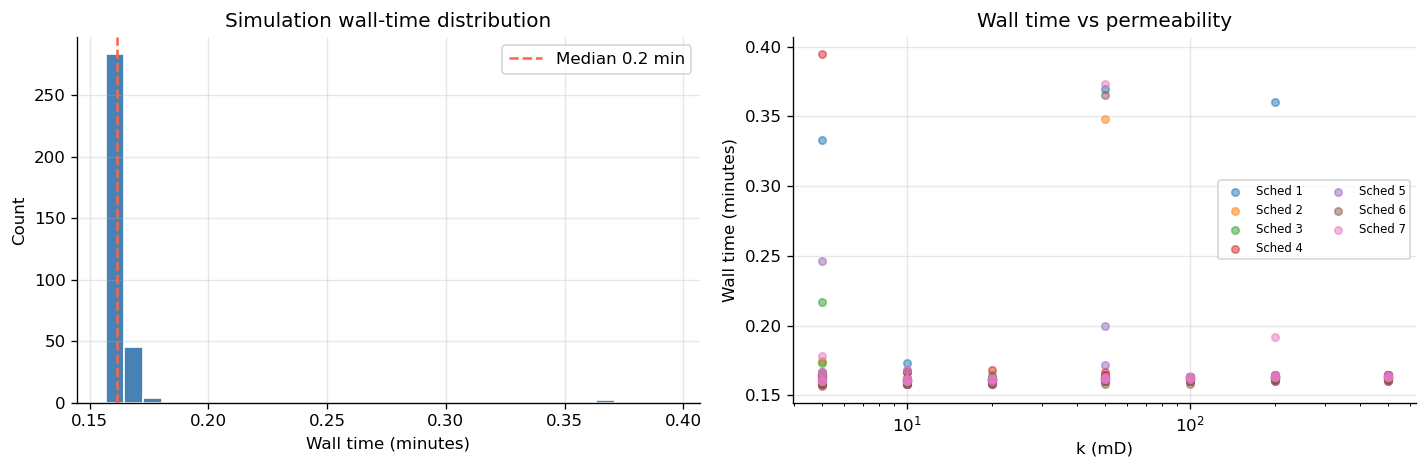

Wall time summary (seconds):
count    343.0
mean      10.0
std        1.8
min        9.4
25%        9.7
50%        9.7
75%        9.8
max       23.7
Name: sim_wall_s, dtype: float64


In [4]:
# ── Simulation wall-time distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ok['sim_wall_s'] / 60, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Wall time (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Simulation wall-time distribution')
axes[0].axvline(ok['sim_wall_s'].median() / 60, color='tomato',
                linestyle='--', label=f"Median {ok['sim_wall_s'].median()/60:.1f} min")
axes[0].legend()

# Wall time vs k  (higher k → faster pressure diffusion → stiffer early → might vary)
for sid in sched_expected:
    sub = ok[ok['schedule_id'] == sid]
    axes[1].scatter(sub['k_mD'], sub['sim_wall_s'] / 60,
                    s=20, alpha=0.5, label=f'Sched {sid}')
axes[1].set_xscale('log')
axes[1].set_xlabel('k (mD)')
axes[1].set_ylabel('Wall time (minutes)')
axes[1].set_title('Wall time vs permeability')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

print(f"Wall time summary (seconds):")
print(ok['sim_wall_s'].describe().round(1))

---
## 2. All `.mat` files loadable, correct array dimensions

In [4]:
import h5py

def load_mat(filepath, key):
    """Load a single variable from a .mat file, handling both v7.2 and v7.3."""
    try:
        # Try scipy first (v7.2 and earlier)
        mat = sio.loadmat(str(filepath), variable_names=[key])
        arr = mat[key]
    except NotImplementedError:
        # Fall back to h5py for v7.3 (HDF5-based)
        with h5py.File(str(filepath), 'r') as f:
            arr = f[key][()]          # [()] loads the full dataset into numpy
            if arr.ndim == 2:
                arr = arr.T           # MATLAB stores column-major; h5py reads transposed
    return arr


issues = []

for _, row in ok.iterrows():
    case_dir = TRAINING_DIR / row['case_name']

    if not case_dir.exists():
        issues.append((row['case_name'], 'folder missing'))
        continue

    # snapshots_psia.mat
    snap_path = case_dir / 'snapshots_psia.mat'
    if not snap_path.exists():
        issues.append((row['case_name'], 'snapshots_psia.mat missing'))
    else:
        try:
            X = load_mat(snap_path, 'X_psia')
            if X.shape[0] != N_CELLS:
                issues.append((row['case_name'],
                                f'snapshots rows={X.shape[0]}, expected {N_CELLS}'))
            if X.shape[1] < N_STEPS * 0.95:
                issues.append((row['case_name'],
                                f'snapshots cols={X.shape[1]}, expected ~{N_STEPS}'))
            if not np.isfinite(X).all():
                issues.append((row['case_name'],
                                f'{(~np.isfinite(X)).sum()} NaN/Inf in snapshots'))
        except Exception as e:
            issues.append((row['case_name'], f'snapshots load error: {e}'))

    # well_data.mat
    wd_path = case_dir / 'well_data.mat'
    if not wd_path.exists():
        issues.append((row['case_name'], 'well_data.mat missing'))
    else:
        try:
            for key in ['bhp_psia', 'delta_p_psi', 'rate_STBd', 'time_hr']:
                load_mat(wd_path, key)   # just check each key is readable
        except Exception as e:
            issues.append((row['case_name'], f'well_data load error: {e}'))

    # params.json
    pj_path = case_dir / 'params.json'
    if not pj_path.exists():
        issues.append((row['case_name'], 'params.json missing'))
    else:
        try:
            with open(pj_path) as f:
                json.load(f)
        except Exception as e:
            issues.append((row['case_name'], f'params.json parse error: {e}'))

if issues:
    print(f'{len(issues)} file integrity issues found:')
    for case, msg in issues[:20]:
        print(f'   [{case}]  {msg}')
else:
    print(f'All {len(ok)} cases passed file integrity check')

All 343 cases passed file integrity check


---
## 3. Helper Functions
Used throughout the remainder of the notebook.

In [5]:
def load_case(case_name):
    """Load all data for a single case. Handles both mat v7.2 and v7.3."""
    case_dir = TRAINING_DIR / case_name

    snap = load_mat(case_dir / 'snapshots_psia.mat', 'X_psia')   # [N_cells, N_t]

    time_hr  = load_mat(case_dir / 'well_data.mat', 'time_hr').ravel()
    bhp_psia = load_mat(case_dir / 'well_data.mat', 'bhp_psia').ravel()
    dp_psi   = load_mat(case_dir / 'well_data.mat', 'delta_p_psi').ravel()
    rate     = load_mat(case_dir / 'well_data.mat', 'rate_STBd').ravel()

    with open(case_dir / 'params.json') as f:
        params = json.load(f)

    return {
        'X'        : snap,
        'time_hr'  : time_hr,
        'bhp_psia' : bhp_psia,
        'dp_psi'   : dp_psi,
        'rate'     : rate,
        'params'   : params,
    }

def bourdet_derivative(t_hr, dp_psi, L=0.2):
    """
    Bourdet derivative  dp' = dp/d(ln t)  using central differences
    with Bourdet smoothing parameter L (log-cycle fraction, default 0.2).

    Returns (t_d, dp_prime) arrays at interior points.
    """
    ln_t  = np.log(t_hr)
    dp_d  = np.full_like(dp_psi, np.nan)

    for i in range(1, len(t_hr) - 1):
        # find left neighbour at least L log-cycles back
        il = i - 1
        while il > 0 and (ln_t[i] - ln_t[il]) < L:
            il -= 1
        # find right neighbour at least L log-cycles ahead
        ir = i + 1
        while ir < len(t_hr) - 1 and (ln_t[ir] - ln_t[i]) < L:
            ir += 1

        dln_l = ln_t[i]  - ln_t[il]
        dln_r = ln_t[ir] - ln_t[i]

        if dln_l > 0 and dln_r > 0:
            dp_d[i] = ((dp_psi[i] - dp_psi[il]) / dln_l * dln_r +
                       (dp_psi[ir] - dp_psi[i]) / dln_r * dln_l) / (dln_l + dln_r)

    mask = np.isfinite(dp_d) & (dp_d > 0) & (dp_psi > 0)
    return t_hr[mask], dp_psi[mask], dp_d[mask]


def analytical_dp_prime(k_mD, h_ft, q_STBd, mu_cp, Bo):
    """Bourdet flat level in the MTR (field units)."""
    return 70.6 * q_STBd * mu_cp * Bo / (k_mD * h_ft)


def analytical_mtr_slope(k_mD, h_ft, q_STBd, mu_cp, Bo):
    """Semi-log MTR slope m [psi/cycle] (field units)."""
    return 162.6 * q_STBd * mu_cp * Bo / (k_mD * h_ft)


def case_name(k_mD, S, sched_id):
    return f'k{round(k_mD):03d}_s{round(S):02d}_sched{sched_id}'


print('Helper functions defined.')

Helper functions defined.


---
## 4. BHP Time Series — One Representative Case per k Value
Schedule 1 (constant 800 STB/d), S = 0.

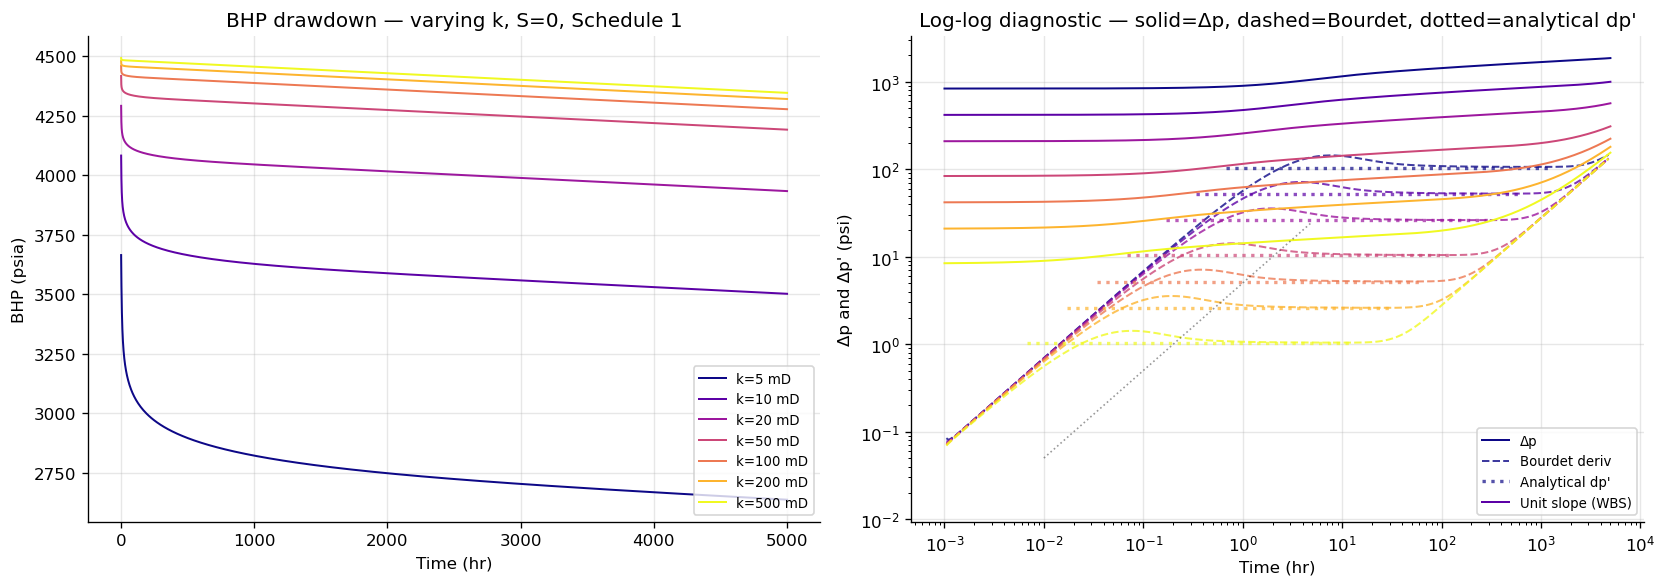

In [6]:
k_vals  = [5, 10, 20, 50, 100, 200, 500]
cmap    = plt.cm.plasma
colors  = [cmap(i / (len(k_vals) - 1)) for i in range(len(k_vals))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k_val, col in zip(k_vals, colors):
    cname = case_name(k_val, 0, 1)
    try:
        d = load_case(cname)
    except FileNotFoundError:
        print(f'  Skipping {cname} — file not found')
        continue

    t  = d['time_hr']
    dp = d['dp_psi']

    # ── Linear scale ─────────────────────────────────────────────────
    axes[0].plot(t, d['bhp_psia'], color=col, lw=1.2, label=f'k={k_val} mD')

    # ── Log-log scale (dp vs t) ───────────────────────────────────────
    t_d, dp_d, dprime = bourdet_derivative(t, dp)
    axes[1].loglog(t,   dp,     color=col,  lw=1.2, ls='-')
    axes[1].loglog(t_d, dprime, color=col,  lw=1.2, ls='--', alpha=0.8)

    # Analytical dp-prime reference line
    p = d['params']
    dp_prime_an = analytical_dp_prime(k_val, p['h_ft'], 800, p['mu_cp'], p['Bo'])
    t_mtr_start = p['t_wbs_end_hr']
    t_mtr_end   = p['t_pss_start_hr']
    axes[1].hlines(dp_prime_an, t_mtr_start, t_mtr_end,
                   color=col, lw=2, ls=':', alpha=0.7)

axes[0].set_xlabel('Time (hr)')
axes[0].set_ylabel('BHP (psia)')
axes[0].set_title('BHP drawdown — varying k, S=0, Schedule 1')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Time (hr)')
axes[1].set_ylabel('Δp and Δp\' (psi)')
axes[1].set_title('Log-log diagnostic — solid=Δp, dashed=Bourdet, dotted=analytical dp\'')
# Unit-slope reference (WBS)
t_ref = np.array([0.01, 5])
axes[1].loglog(t_ref, t_ref * 5, 'k:', lw=1, alpha=0.4, label='Unit slope ref')
axes[1].legend(['Δp', 'Bourdet deriv', 'Analytical dp\'', 'Unit slope (WBS)'],
               fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Flow Regime Coverage — All (k, S) Pairs, Schedule 1

✓  All 49 (k,S) pairs have WBS + MTR + BDF timesteps


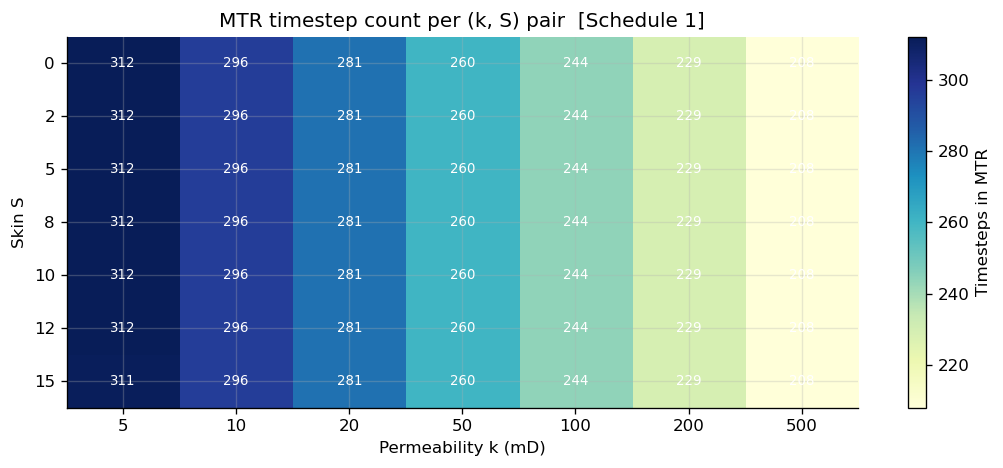

In [7]:
# ── Check that all three regimes have data points ─────────────────────────
S_vals = [0, 2, 5, 8, 10, 12, 15]

records = []
for k_val in k_vals:
    for S_val in S_vals:
        cname = case_name(k_val, S_val, 1)
        try:
            d = load_case(cname)
        except FileNotFoundError:
            records.append(dict(k=k_val, S=S_val,
                                n_wbs=0, n_mtr=0, n_bdf=0, status='MISSING'))
            continue

        p     = d['params']
        t     = d['time_hr']
        t_end = t[-1]

        # ── Robust regime boundaries ──────────────────────────────────
        # The analytical t_wbs formula breaks down at high skin because
        # exp(2S) grows without bound. Cap at 10% of simulation window
        # so the checker does not flag physically valid high-skin cases.
        t_wbs_raw = p['t_wbs_end_hr']
        t_pss     = p['t_pss_start_hr']

        # If t_wbs exceeds the simulation window, the entire run is
        # WBS-dominated by the analytical criterion. Use the Bourdet
        # derivative to detect the flat MTR region instead.
        t_d, dp_d, dprime = bourdet_derivative(t, d['dp_psi'])
        if len(dprime) > 5:
            # Flat region: Bourdet std/mean < 0.15 over a window
            dprime_norm = dprime / (dprime.max() + 1e-10)
            rolling_cv  = pd.Series(dprime_norm).rolling(10, min_periods=5).std() / \
                          (pd.Series(dprime_norm).rolling(10, min_periods=5).mean() + 1e-10)
            flat_mask   = rolling_cv < 0.15
            if flat_mask.sum() > 5:
                # Use Bourdet-based boundaries instead of analytical
                t_wbs_use = float(t_d[np.argmax(flat_mask.values)])
                t_pss_use = min(t_pss, t_end)
            else:
                # Truly WBS-dominated — no flat region visible
                t_wbs_use = t_end * 0.8
                t_pss_use = t_end * 0.9
        else:
            t_wbs_use = min(t_wbs_raw, t_end * 0.1)
            t_pss_use = min(t_pss,     t_end)

        n_wbs = int((t <  t_wbs_use).sum())
        n_mtr = int(((t >= t_wbs_use) & (t < t_pss_use)).sum())
        n_bdf = int((t >= t_pss_use).sum())

        # Only flag as NO_MTR if truly no flat Bourdet region exists
        status = 'OK'
        if n_mtr < 3 and t_wbs_raw < t_end:
            status = 'NO_MTR'
        if n_bdf < 2:
            status = 'NO_BDF' if status == 'OK' else status + '+NO_BDF'

        records.append(dict(k=k_val, S=S_val,
                            n_wbs=n_wbs, n_mtr=n_mtr, n_bdf=n_bdf,
                            t_wbs_analytical=round(t_wbs_raw, 2),
                            t_wbs_used=round(t_wbs_use, 2),
                            t_pss=round(t_pss, 1),
                            status=status))

regime_df = pd.DataFrame(records)
problems  = regime_df[regime_df['status'] != 'OK']

if len(problems) > 0:
    print(f'{len(problems)} (k,S) pairs with regime coverage issues:')
    print(problems.to_string())
else:
    print(f'✓  All {len(regime_df)} (k,S) pairs have WBS + MTR + BDF timesteps')

# Pivot to heatmap: MTR timestep count
pivot_mtr = regime_df.pivot(index='S', columns='k', values='n_mtr')

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot_mtr.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(k_vals)))
ax.set_xticklabels(k_vals)
ax.set_yticks(range(len(S_vals)))
ax.set_yticklabels(S_vals)
ax.set_xlabel('Permeability k (mD)')
ax.set_ylabel('Skin S')
ax.set_title('MTR timestep count per (k, S) pair  [Schedule 1]')
for i in range(len(S_vals)):
    for j in range(len(k_vals)):
        val = pivot_mtr.values[i, j]
        ax.text(j, i, str(int(val)) if np.isfinite(val) else '?',
                ha='center', va='center', fontsize=8,
                color='white' if val > pivot_mtr.values.max() * 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Timesteps in MTR')
plt.tight_layout()
plt.show()

---
## 6. Bourdet Derivative — Full Grid Survey, Schedule 1
Each subplot: one k value, all S values overlaid.

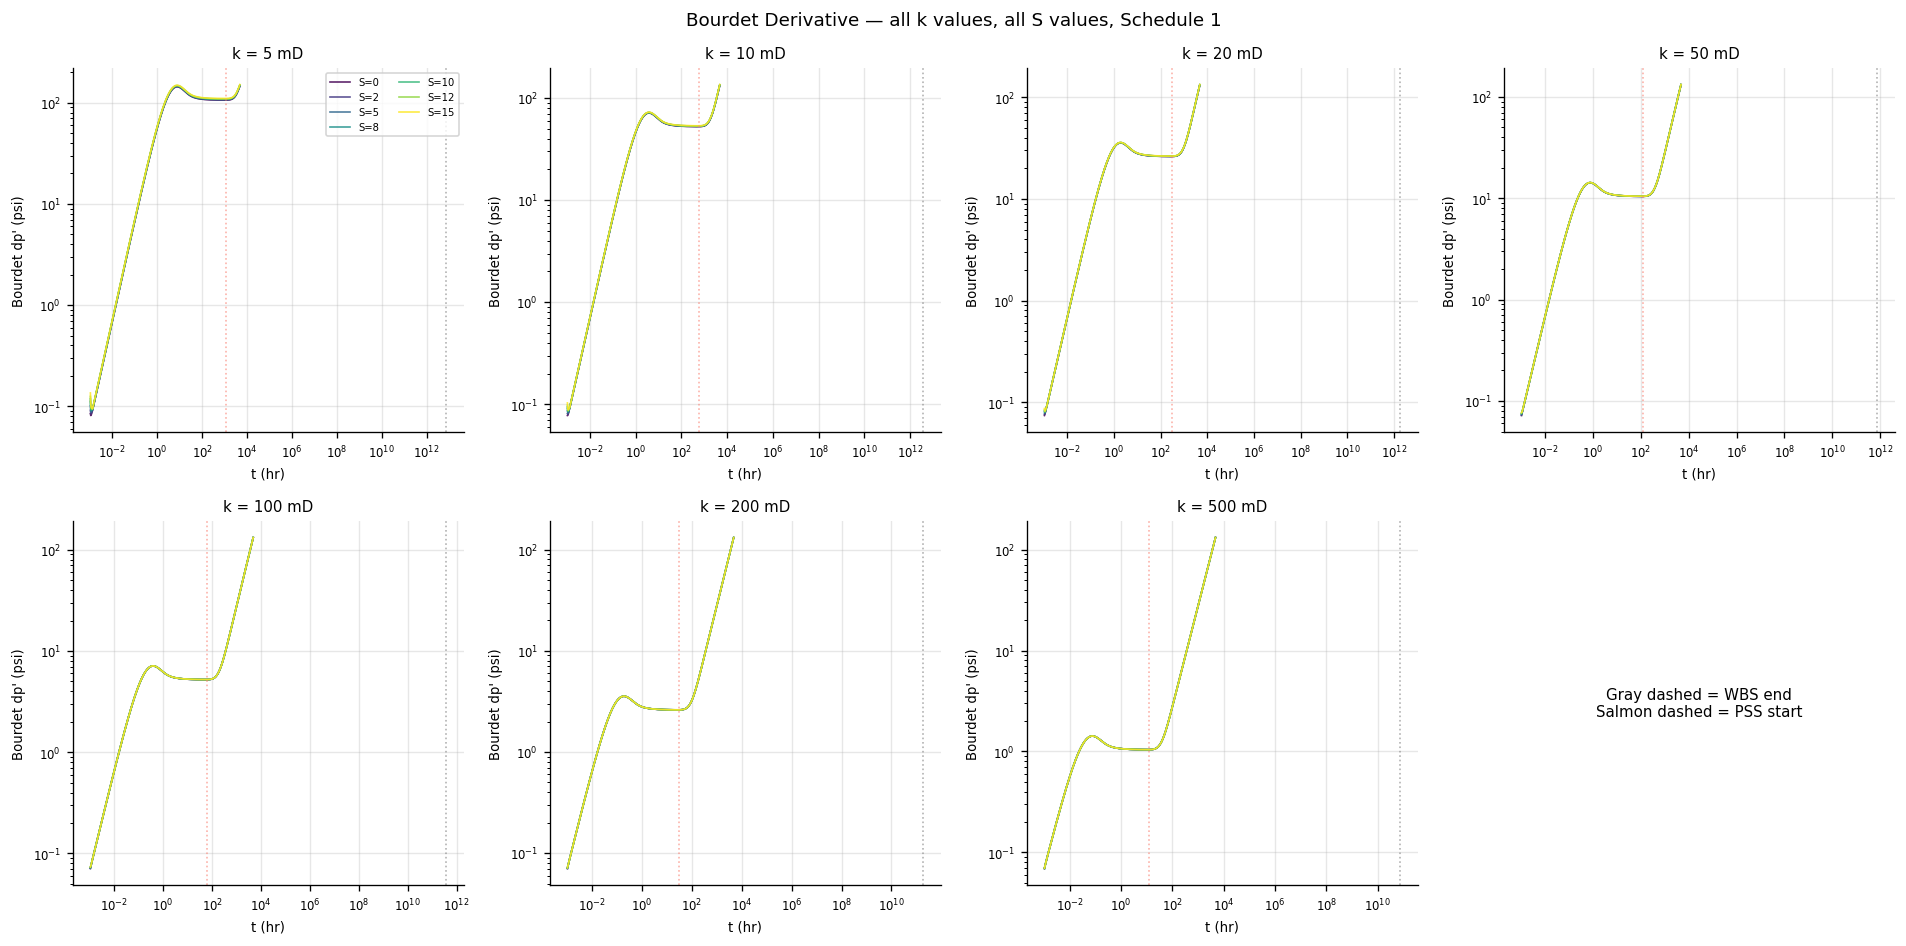

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.ravel()
s_cmap   = plt.cm.viridis
s_colors = [s_cmap(i / (len(S_vals) - 1)) for i in range(len(S_vals))]

for ik, k_val in enumerate(k_vals):
    ax = axes[ik]
    for S_val, scol in zip(S_vals, s_colors):
        cname = case_name(k_val, S_val, 1)
        try:
            d = load_case(cname)
        except FileNotFoundError:
            continue

        t  = d['time_hr']
        dp = d['dp_psi']
        t_d, dp_d, dprime = bourdet_derivative(t, dp)

        ax.loglog(t_d, dprime, color=scol, lw=1.0, alpha=0.85, label=f'S={S_val}')

    # Reference lines
    p_ref = d['params']   # use last loaded case for regime boundaries
    ax.axvline(p_ref['t_wbs_end_hr'],   color='gray',   ls=':', lw=1, alpha=0.6)
    ax.axvline(p_ref['t_pss_start_hr'], color='salmon', ls=':', lw=1, alpha=0.6)
    ax.set_title(f'k = {k_val} mD', fontsize=9)
    ax.set_xlabel('t (hr)', fontsize=8)
    ax.set_ylabel('Bourdet dp\' (psi)', fontsize=8)
    ax.tick_params(labelsize=7)
    if ik == 0:
        ax.legend(fontsize=6, ncol=2)

# Hide the 8th unused subplot
axes[-1].axis('off')
axes[-1].text(0.5, 0.5, 'Gray dashed = WBS end\nSalmon dashed = PSS start',
              ha='center', va='center', transform=axes[-1].transAxes, fontsize=9)

fig.suptitle('Bourdet Derivative — all k values, all S values, Schedule 1', fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Cross-Case Scaling Checks
### 7a. dp-prime should scale as 1/k

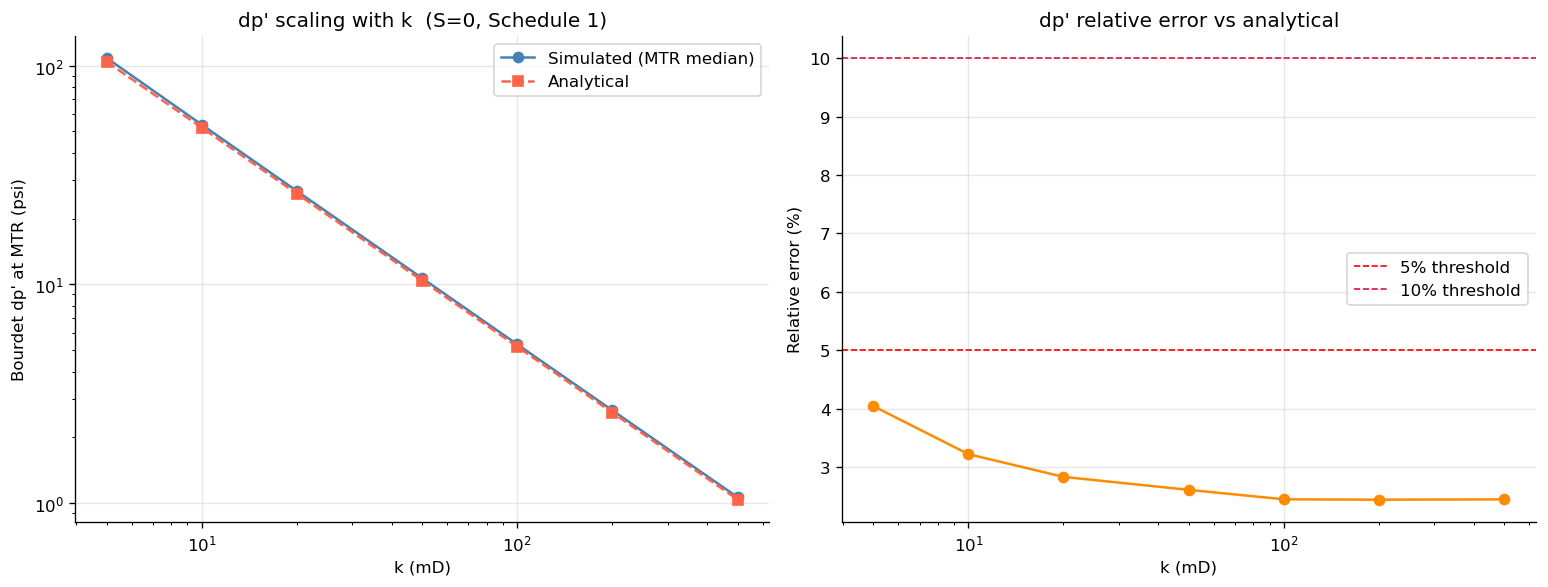

 k_mD  dp_prime_sim  dp_prime_an  rel_error_pct
    5        108.12       103.92           4.04
   10         53.63        51.96           3.22
   20         26.72        25.98           2.83
   50         10.66        10.39           2.61
  100          5.32         5.20           2.45
  200          2.66         2.60           2.44
  500          1.06         1.04           2.45


In [9]:
# ── Read MTR dp-prime from Bourdet derivative and compare to analytical ────
scaling_records = []

for k_val in k_vals:
    cname = case_name(k_val, 0, 1)   # S=0, sched 1
    try:
        d = load_case(cname)
    except FileNotFoundError:
        continue

    p  = d['params']
    t  = d['time_hr']
    dp = d['dp_psi']

    t_d, dp_d, dprime = bourdet_derivative(t, dp)

    # Take median of Bourdet derivative in the MTR window
    mtr_mask = (t_d >= p['t_wbs_end_hr']) & (t_d <= p['t_pss_start_hr'])
    dp_prime_sim = float(np.median(dprime[mtr_mask])) if mtr_mask.sum() > 0 else np.nan
    dp_prime_an  = analytical_dp_prime(k_val, p['h_ft'], 800, p['mu_cp'], p['Bo'])

    scaling_records.append(dict(
        k_mD         = k_val,
        dp_prime_sim = dp_prime_sim,
        dp_prime_an  = dp_prime_an,
        rel_error_pct= abs(dp_prime_sim - dp_prime_an) / dp_prime_an * 100
            if np.isfinite(dp_prime_sim) else np.nan
    ))

sc_df = pd.DataFrame(scaling_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(sc_df['k_mD'], sc_df['dp_prime_sim'], 'o-', color='steelblue',
               label='Simulated (MTR median)')
axes[0].loglog(sc_df['k_mD'], sc_df['dp_prime_an'],  's--', color='tomato',
               label='Analytical')
axes[0].set_xlabel('k (mD)')
axes[0].set_ylabel('Bourdet dp\' at MTR (psi)')
axes[0].set_title('dp\' scaling with k  (S=0, Schedule 1)')
axes[0].legend()

axes[1].semilogx(sc_df['k_mD'], sc_df['rel_error_pct'], 'o-', color='darkorange')
axes[1].axhline(5,  color='red',    ls='--', lw=1, label='5% threshold')
axes[1].axhline(10, color='crimson',ls='--', lw=1, label='10% threshold')
axes[1].set_xlabel('k (mD)')
axes[1].set_ylabel('Relative error (%)')
axes[1].set_title('dp\' relative error vs analytical')
axes[1].legend()

plt.tight_layout()
plt.show()

print(sc_df.to_string(index=False, float_format='%.2f'))

### 7b. MTR semi-log slope scales as 1/k

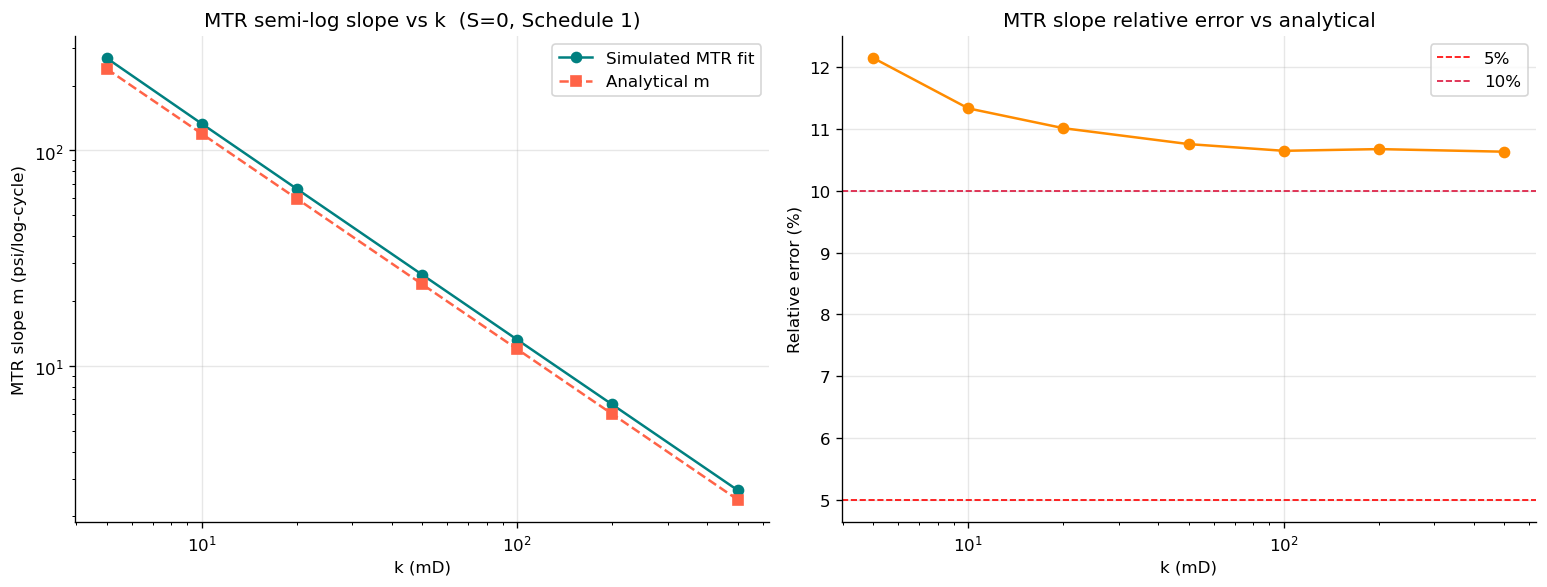

 k_mD  slope_sim  slope_an  rel_err_pct
    5     268.43    239.35        12.15
   10     133.24    119.67        11.34
   20      66.43     59.84        11.02
   50      26.51     23.93        10.76
  100      13.24     11.97        10.65
  200       6.62      5.98        10.68
  500       2.65      2.39        10.64


In [10]:
slope_records = []

for k_val in k_vals:
    cname = case_name(k_val, 0, 1)
    try:
        d = load_case(cname)
    except FileNotFoundError:
        continue

    p  = d['params']
    t  = d['time_hr']
    dp = d['dp_psi']

    # Fit a line dp vs log10(t) in the MTR window
    mtr_mask = (t >= p['t_wbs_end_hr']) & (t <= p['t_pss_start_hr'])
    if mtr_mask.sum() < 3:
        slope_sim = np.nan
    else:
        coeffs    = np.polyfit(np.log10(t[mtr_mask]), dp[mtr_mask], 1)
        slope_sim = coeffs[0]   # psi / log-cycle

    slope_an = analytical_mtr_slope(k_val, p['h_ft'], 800, p['mu_cp'], p['Bo'])

    slope_records.append(dict(
        k_mD       = k_val,
        slope_sim  = slope_sim,
        slope_an   = slope_an,
        rel_err_pct= abs(slope_sim - slope_an) / slope_an * 100
            if np.isfinite(slope_sim) else np.nan
    ))

sl_df = pd.DataFrame(slope_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(sl_df['k_mD'], sl_df['slope_sim'], 'o-', color='teal',
               label='Simulated MTR fit')
axes[0].loglog(sl_df['k_mD'], sl_df['slope_an'],  's--', color='tomato',
               label='Analytical m')
axes[0].set_xlabel('k (mD)')
axes[0].set_ylabel('MTR slope m (psi/log-cycle)')
axes[0].set_title('MTR semi-log slope vs k  (S=0, Schedule 1)')
axes[0].legend()

axes[1].semilogx(sl_df['k_mD'], sl_df['rel_err_pct'], 'o-', color='darkorange')
axes[1].axhline(5,  color='red',    ls='--', lw=1, label='5%')
axes[1].axhline(10, color='crimson',ls='--', lw=1, label='10%')
axes[1].set_xlabel('k (mD)')
axes[1].set_ylabel('Relative error (%)')
axes[1].set_title('MTR slope relative error vs analytical')
axes[1].legend()

plt.tight_layout()
plt.show()

print(sl_df.to_string(index=False, float_format='%.2f'))

### 7c. Skin effect — BHP shift with S at constant k

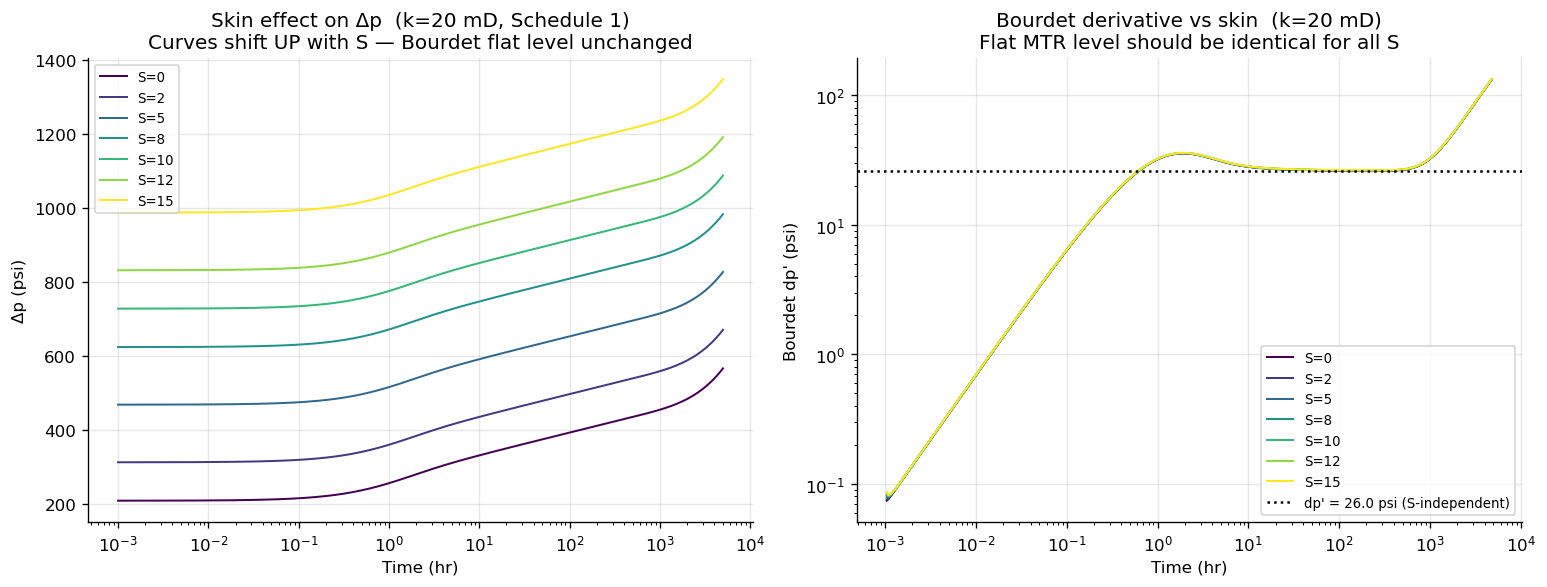

In [11]:
k_test = 20    # mD — matches your original baseline

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for S_val, scol in zip(S_vals, s_colors):
    cname = case_name(k_test, S_val, 1)
    try:
        d = load_case(cname)
    except FileNotFoundError:
        continue

    t  = d['time_hr']
    dp = d['dp_psi']
    t_d, dp_d, dprime = bourdet_derivative(t, dp)

    axes[0].semilogx(t,   dp,     color=scol, lw=1.2, label=f'S={S_val}')
    axes[1].loglog  (t_d, dprime, color=scol, lw=1.2, label=f'S={S_val}')

# Skin shift: Δdp_skin = 0.869 * m * S
# The Bourdet derivative flat level is INDEPENDENT of S — only Δp shifts
p_ref = load_case(case_name(k_test, 0, 1))['params']
dp_prime_expected = analytical_dp_prime(k_test, p_ref['h_ft'], 800, p_ref['mu_cp'], p_ref['Bo'])
axes[1].axhline(dp_prime_expected, color='black', ls=':', lw=1.5,
                label=f"dp' = {dp_prime_expected:.1f} psi (S-independent)")

axes[0].set_xlabel('Time (hr)')
axes[0].set_ylabel('Δp (psi)')
axes[0].set_title(f'Skin effect on Δp  (k={k_test} mD, Schedule 1)\n'
                  f'Curves shift UP with S — Bourdet flat level unchanged')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Time (hr)')
axes[1].set_ylabel('Bourdet dp\' (psi)')
axes[1].set_title(f'Bourdet derivative vs skin  (k={k_test} mD)\n'
                  f'Flat MTR level should be identical for all S')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 8. Rate Schedule Fidelity
Verify that the extracted `rate_STBd` matches the intended schedule for all 7 schedule types.

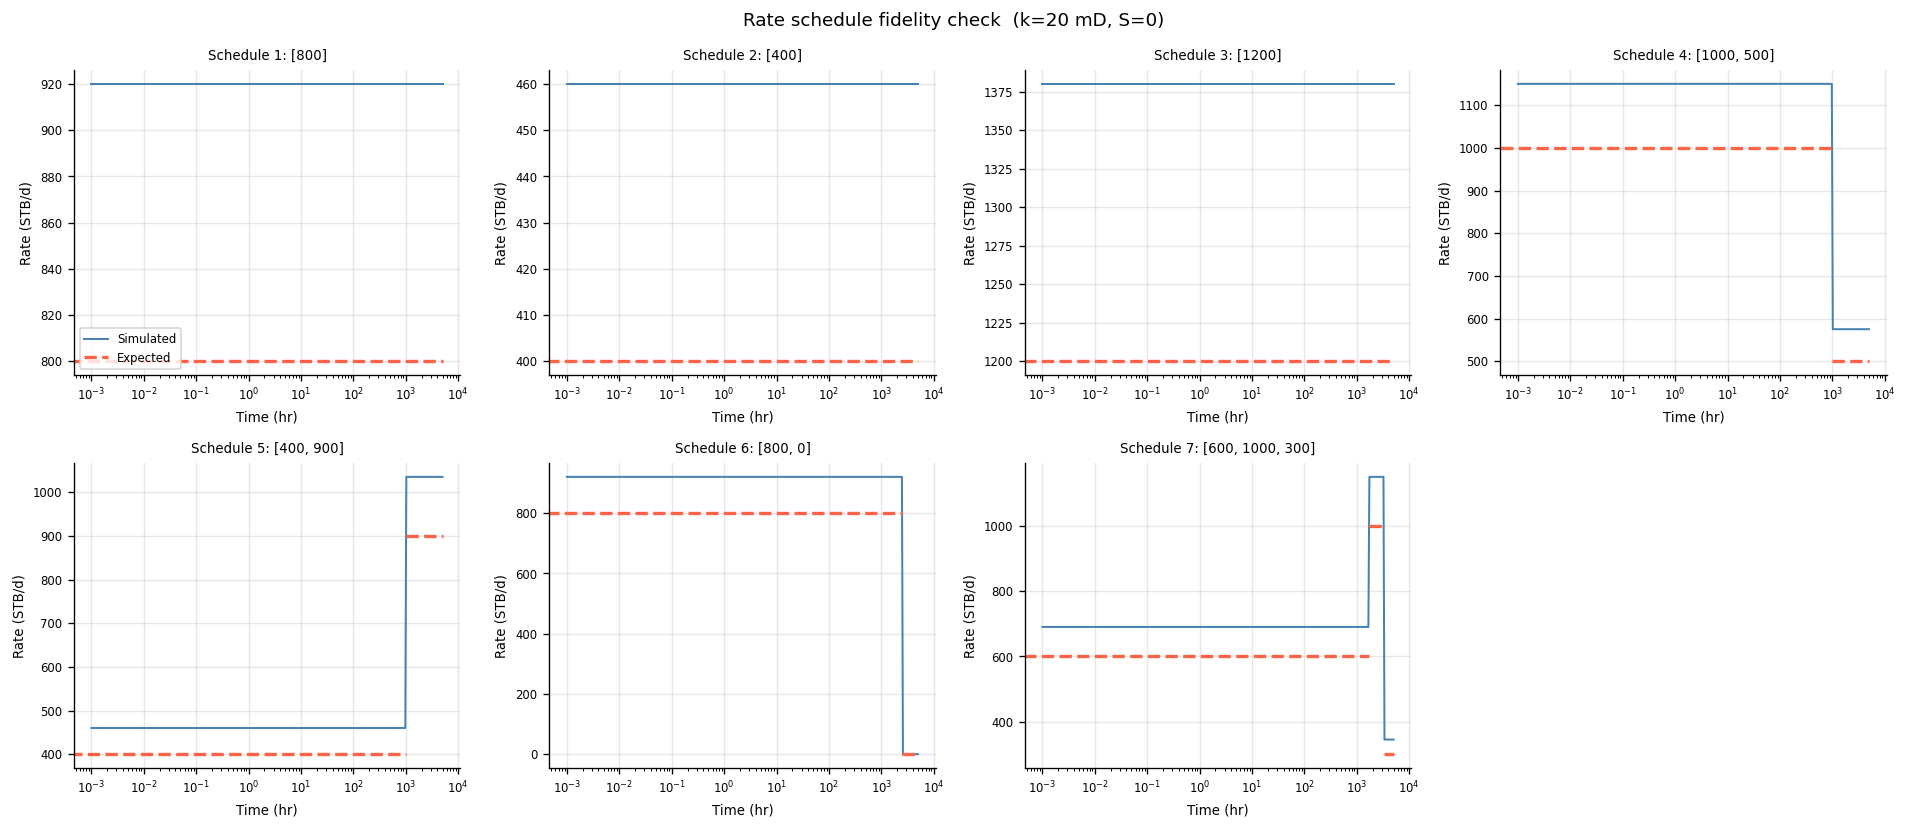

11 rate period mismatches:
           case  sched  period  r_expected  r_simulated  err_pct
k020_s00_sched1      1       1         800        920.0     15.0
k020_s00_sched2      2       1         400        460.0     15.0
k020_s00_sched3      3       1        1200       1380.0     15.0
k020_s00_sched4      4       1        1000       1150.0     15.0
k020_s00_sched4      4       2         500        575.0     15.0
k020_s00_sched5      5       1         400        460.0     15.0
k020_s00_sched5      5       2         900       1035.0     15.0
k020_s00_sched6      6       1         800        920.0     15.0
k020_s00_sched7      7       1         600        690.0     15.0
k020_s00_sched7      7       2        1000       1150.0     15.0
k020_s00_sched7      7       3         300        345.0     15.0


In [12]:
# Intended rates and change times for each schedule
SCHED_SPEC = {
    1: {'rates': [800],              'changes': []},
    2: {'rates': [400],              'changes': []},
    3: {'rates': [1200],             'changes': []},
    4: {'rates': [1000, 500],        'changes': [1000]},
    5: {'rates': [400,  900],        'changes': [1000]},
    6: {'rates': [800,  0],          'changes': [2500]},
    7: {'rates': [600, 1000, 300],   'changes': [1667, 3333]},
}

# Use k=20 mD, S=0 to check all schedules
k_check = 20
S_check = 0
tol_pct = 2.0   # allow 2% relative tolerance on rate

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.ravel()

sched_issues = []

for sid in range(1, 8):
    ax    = axes[sid - 1]
    spec  = SCHED_SPEC[sid]
    cname_s = case_name(k_check, S_check, sid)
    try:
        d = load_case(cname_s)
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'File not found', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f'Schedule {sid}')
        continue

    t    = d['time_hr']
    rate = d['rate']

    ax.plot(t, rate, lw=1.2, color='steelblue', label='Simulated')

    # Draw expected step function
    changes = [0] + spec['changes'] + [t[-1] * 1.01]
    for ip, (t0, t1, r) in enumerate(zip(changes[:-1], changes[1:], spec['rates'])):
        ax.hlines(r, t0, t1, color='tomato', lw=2.0, ls='--',
                  label='Expected' if ip == 0 else None)

    # Check each rate period
    for ip, (r_exp, t_change) in enumerate(zip(spec['rates'], spec['changes'] + [None])):
        t_start_seg = spec['changes'][ip - 1] if ip > 0 else 0
        t_end_seg   = t_change if t_change is not None else t[-1]
        mask = (t >= t_start_seg + 0.1) & (t <= t_end_seg * 0.9)   # interior of period
        if mask.sum() > 0:
            r_sim = np.median(rate[mask])
            err   = abs(r_sim - r_exp) / max(r_exp, 1) * 100
            if err > tol_pct and r_exp > 0:
                sched_issues.append(dict(
                    case=cname_s, sched=sid, period=ip+1,
                    r_expected=r_exp, r_simulated=round(r_sim, 1), err_pct=round(err, 1)
                ))

    ax.set_xscale('log')
    ax.set_xlabel('Time (hr)', fontsize=8)
    ax.set_ylabel('Rate (STB/d)', fontsize=8)
    ax.set_title(f'Schedule {sid}: {spec["rates"]}', fontsize=8)
    ax.tick_params(labelsize=7)
    if sid == 1:
        ax.legend(fontsize=7)

axes[-1].axis('off')
fig.suptitle(f'Rate schedule fidelity check  (k={k_check} mD, S={S_check})', fontsize=11)
plt.tight_layout()
plt.show()

if sched_issues:
    print(f'{len(sched_issues)} rate period mismatches:')
    print(pd.DataFrame(sched_issues).to_string(index=False))
else:
    print(f'✓  All schedule rates match expected values within {tol_pct}%')

---
## 9. Snapshot Spatial Structure
Verify that the pressure drawdown cone is centred on the well cell.

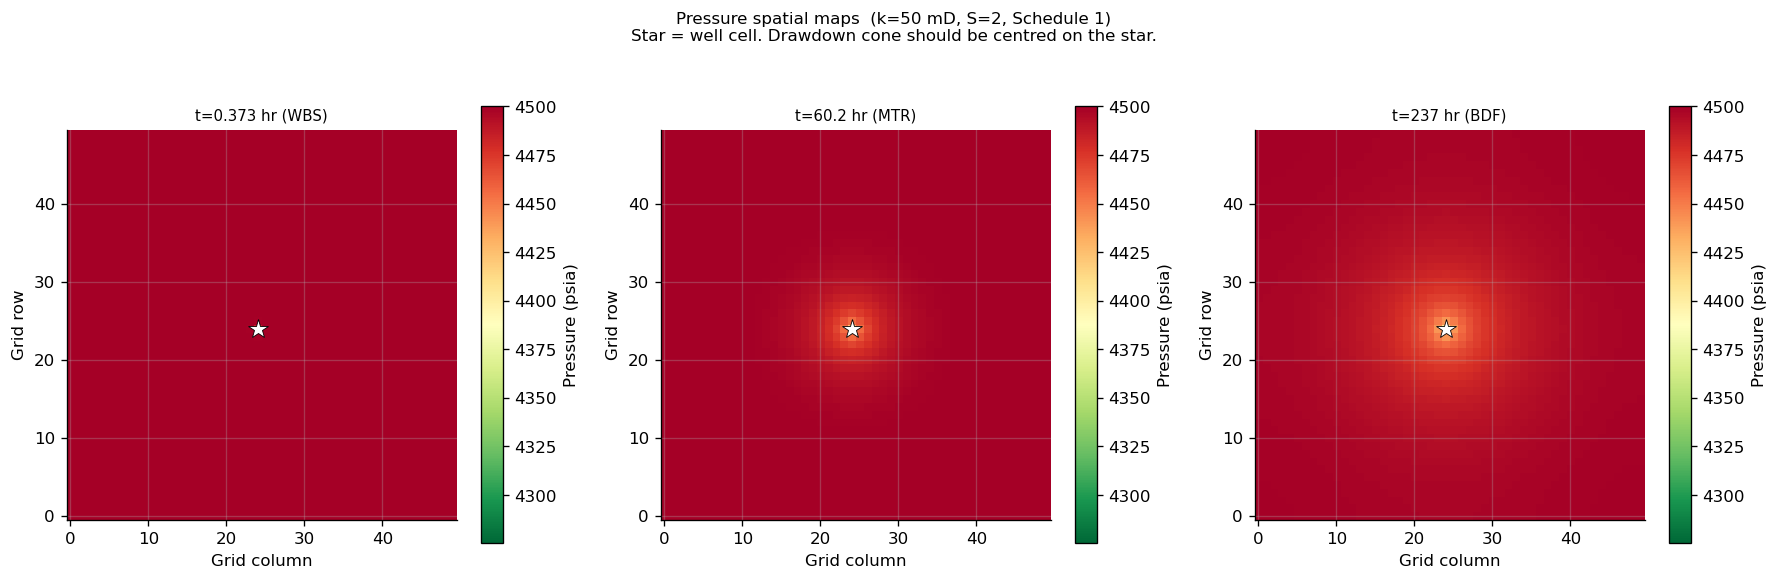

✓  Well cell is the minimum-pressure cell at all 350 timesteps.


In [13]:
# ── Plot spatial pressure maps at WBS / MTR / BDF snapshots ───────────────
k_test = 50   # pick a mid-range case
S_test = 2
d = load_case(case_name(k_test, S_test, 1))

X     = d['X']           # [2500, N_t]
t     = d['time_hr']
p     = d['params']

# Pick three representative time indices
t_wbs_idx = np.argmin(np.abs(t - min(p['t_wbs_end_hr'] * 0.1, t[-1])))
t_mtr_idx = np.argmin(np.abs(t - (p['t_wbs_end_hr'] + p['t_pss_start_hr']) / 2))
t_bdf_idx = np.argmin(np.abs(t - min(p['t_pss_start_hr'] * 2, t[-1])))

snap_indices = [t_wbs_idx, t_mtr_idx, t_bdf_idx]
snap_labels  = [
    f't={t[t_wbs_idx]:.3f} hr (WBS)',
    f't={t[t_mtr_idx]:.1f} hr (MTR)',
    f't={t[t_bdf_idx]:.0f} hr (BDF)',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx, lbl in zip(axes, snap_indices, snap_labels):
    pressure_map = X[:, idx].reshape(NY, NX)
    im = ax.imshow(pressure_map, origin='lower', cmap='RdYlGn_r',
                   vmin=X[:, -1].min(), vmax=P_INIT_PSIA)
    # Mark well cell
    well_col = WELL_CELL_PY % NX
    well_row = WELL_CELL_PY // NX
    ax.plot(well_col, well_row, 'w*', ms=12, markeredgecolor='black',
            markeredgewidth=0.5)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel('Grid column')
    ax.set_ylabel('Grid row')
    plt.colorbar(im, ax=ax, label='Pressure (psia)', shrink=0.85)

fig.suptitle(f'Pressure spatial maps  (k={k_test} mD, S={S_test}, Schedule 1)\n'
             f'Star = well cell. Drawdown cone should be centred on the star.',
             fontsize=10)
plt.tight_layout()
plt.show()

# Quantitative check: well cell must be the lowest-pressure cell at all times
well_p  = X[WELL_CELL_PY, :]
min_p   = X.min(axis=0)
n_wrong = (well_p > min_p + 0.5).sum()   # allow 0.5 psi tolerance

if n_wrong > 0:
    print(f'In {n_wrong} timesteps, well cell is NOT the lowest-pressure cell.')
    print('    This could indicate a wrong well cell index.')
else:
    print(f'✓  Well cell is the minimum-pressure cell at all {X.shape[1]} timesteps.')

---
## 10. Pressure Range Sanity — Full Dataset

All 343 cases have physically plausible pressure ranges.


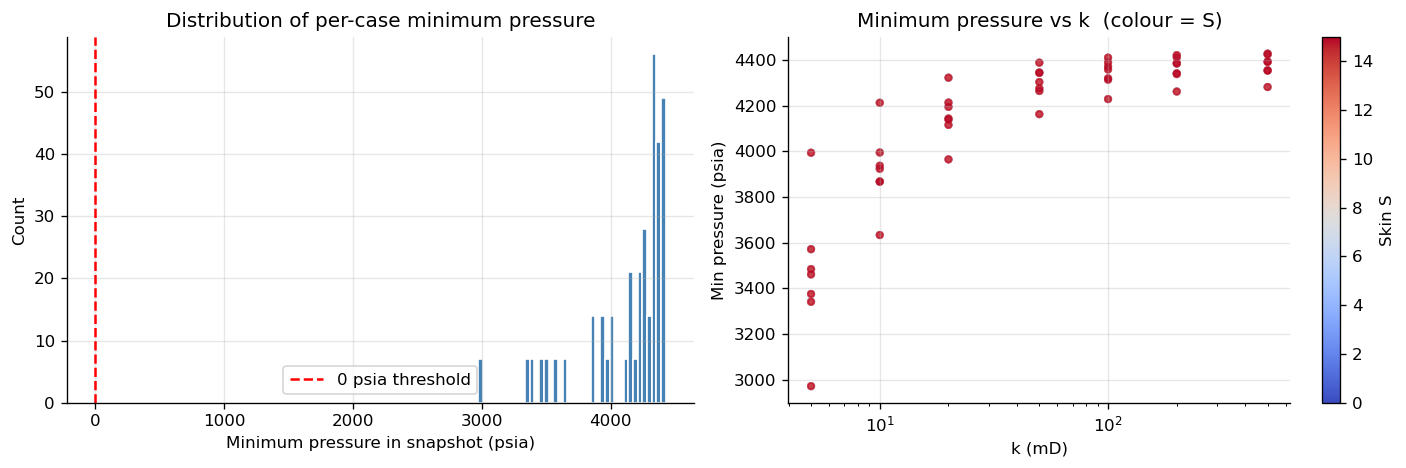

In [14]:
range_records = []
range_issues  = []

for _, row in ok.iterrows():
    snap_path = TRAINING_DIR / row['case_name'] / 'snapshots_psia.mat'
    if not snap_path.exists():
        continue
    try:
        X = load_mat(snap_path, 'X_psia')        # uses the h5py-aware loader
    except Exception as e:
        range_issues.append({'case_name': row['case_name'],
                             'flags': f'load error: {e}'})
        continue

    p_min = float(X.min())
    p_max = float(X.max())
    p_ini = float(X[:, 0].mean())

    flag = ''
    if p_min < 0:
        flag += ' NEGATIVE_PRESSURE'
    if p_max > P_INIT_PSIA + 10:
        flag += ' EXCEEDS_INIT'
    if abs(p_ini - P_INIT_PSIA) > 20:
        flag += ' WRONG_INITIAL'

    record = dict(
        case_name = row['case_name'],
        k_mD      = row['k_mD'],
        S_skin    = row['S_skin'],
        sched     = row['schedule_id'],
        p_min     = round(p_min, 1),
        p_max     = round(p_max, 1),
        p_initial = round(p_ini, 1),
        flags     = flag.strip(),
    )
    range_records.append(record)
    if flag:
        range_issues.append(record)

# ── Guard: check the list is not empty before building DataFrame ──────
if not range_records:
    print('range_records is empty — no cases were loaded successfully.')
    print('Check that load_mat (Section 3) is defined and working.')
    rng_df = pd.DataFrame(columns=['case_name','k_mD','S_skin',
                                   'sched','p_min','p_max','p_initial','flags'])
else:
    rng_df = pd.DataFrame(range_records)
    if range_issues:
        print(f'{len(range_issues)} pressure range issues:')
        print(pd.DataFrame(range_issues).to_string(index=False))
    else:
        print(f'All {len(rng_df)} cases have physically plausible pressure ranges.')

    # ── Distribution plots ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(rng_df['p_min'], bins=40, color='steelblue', edgecolor='white')
    axes[0].axvline(0, color='red', ls='--', lw=1.5, label='0 psia threshold')
    axes[0].set_xlabel('Minimum pressure in snapshot (psia)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of per-case minimum pressure')
    axes[0].legend()

    axes[1].scatter(rng_df['k_mD'], rng_df['p_min'],
                    c=rng_df['S_skin'], cmap='coolwarm', s=15, alpha=0.6)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('k (mD)')
    axes[1].set_ylabel('Min pressure (psia)')
    axes[1].set_title('Minimum pressure vs k  (colour = S)')
    sm = plt.cm.ScalarMappable(cmap='coolwarm',
         norm=plt.Normalize(rng_df['S_skin'].min(), rng_df['S_skin'].max()))
    plt.colorbar(sm, ax=axes[1], label='Skin S')
    plt.tight_layout()
    plt.show()

---
## 11. Multi-Rate Schedule — BHP Continuity Check
At each rate change, BHP should be continuous (no jump) but its derivative should change.

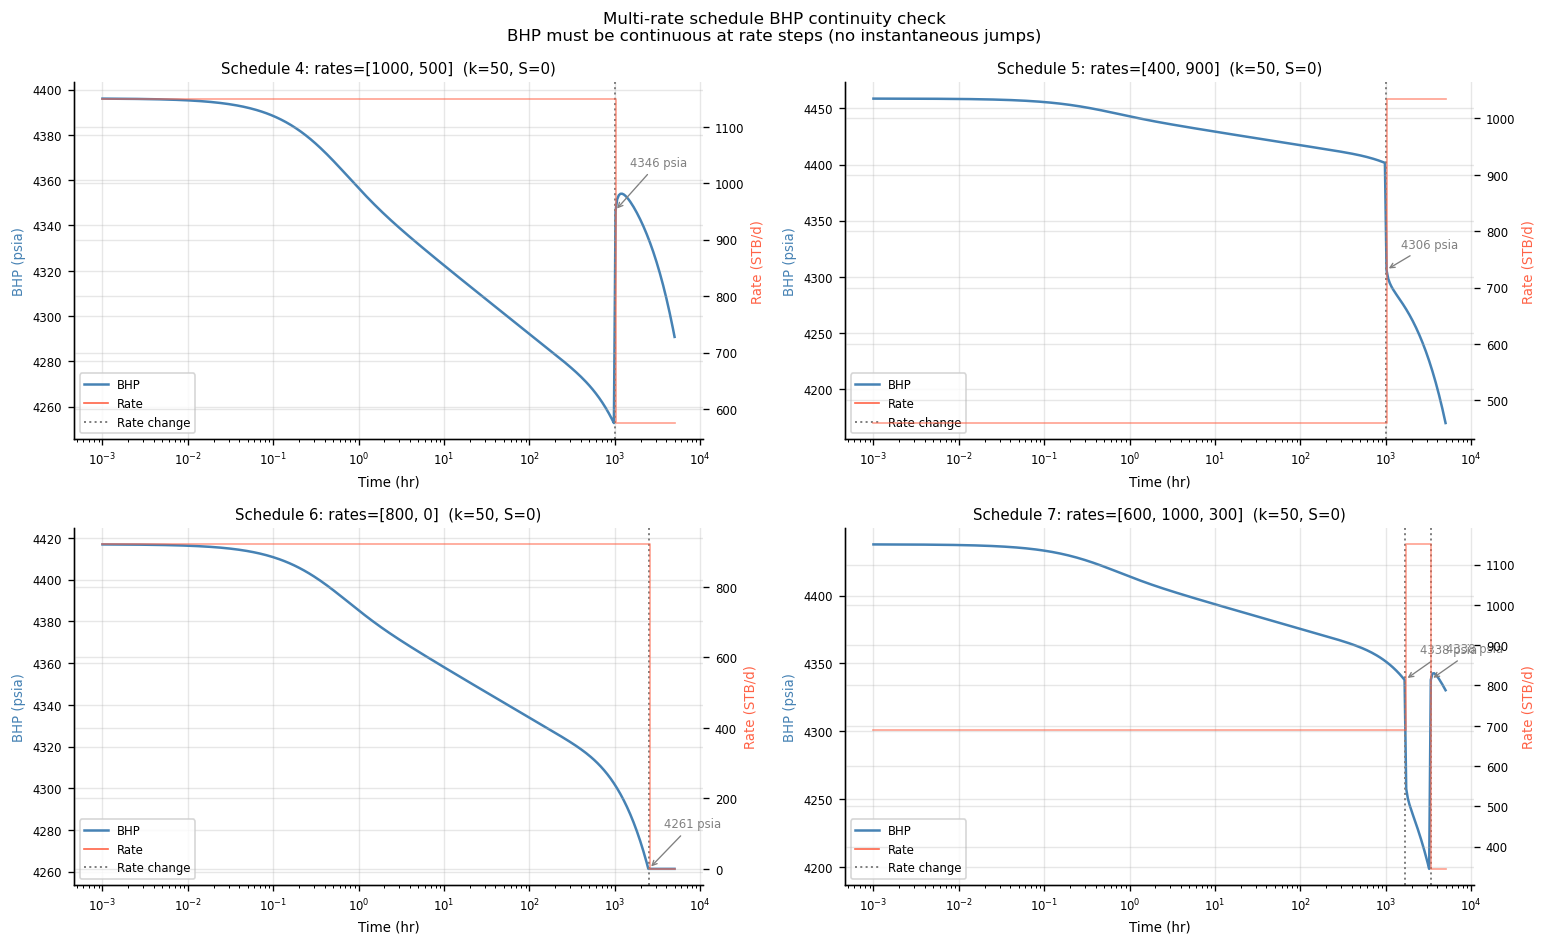

In [15]:
# ── Check schedules 4, 5, 6, 7 for BHP continuity at rate steps ───────────
multi_scheds = [4, 5, 6, 7]
k_check = 50
S_check = 0

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for idx, sid in enumerate(multi_scheds):
    ax    = axes[idx]
    spec  = SCHED_SPEC[sid]
    cname_s = case_name(k_check, S_check, sid)
    try:
        d = load_case(cname_s)
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'File not found', ha='center', va='center',
                transform=ax.transAxes)
        continue

    t   = d['time_hr']
    bhp = d['bhp_psia']
    rt  = d['rate']

    ax2 = ax.twinx()
    ax.plot(t, bhp, 'steelblue', lw=1.5, label='BHP')
    ax2.step(t, rt, 'tomato', lw=1.0, alpha=0.6, where='post', label='Rate')

    # Mark rate change times with vertical lines
    for tc in spec['changes']:
        ax.axvline(tc, color='gray', ls=':', lw=1.2)
        # Find timestep closest to change time and print BHP value
        idx_change = np.argmin(np.abs(t - tc))
        ax.annotate(f'{bhp[idx_change]:.0f} psia',
                    xy=(tc, bhp[idx_change]),
                    xytext=(tc * 1.5, bhp[idx_change] + 20),
                    fontsize=7, color='gray',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

    ax.set_xscale('log')
    ax.set_xlabel('Time (hr)', fontsize=8)
    ax.set_ylabel('BHP (psia)', fontsize=8, color='steelblue')
    ax2.set_ylabel('Rate (STB/d)', fontsize=8, color='tomato')
    ax.set_title(f'Schedule {sid}: rates={spec["rates"]}  (k={k_check}, S={S_check})',
                 fontsize=9)
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)

    # Lines for legend
    lines  = [plt.Line2D([0],[0], color='steelblue', lw=1.5),
              plt.Line2D([0],[0], color='tomato',    lw=1.0),
              plt.Line2D([0],[0], color='gray',      ls=':', lw=1.2)]
    labels = ['BHP', 'Rate', 'Rate change']
    ax.legend(lines, labels, fontsize=7)

fig.suptitle('Multi-rate schedule BHP continuity check\n'
             'BHP must be continuous at rate steps (no instantaneous jumps)',
             fontsize=10)
plt.tight_layout()
plt.show()

---
## 12. Summary Report

In [16]:
print('=' * 62)
print(' DATA QUALITY CHECK — SUMMARY REPORT')
print('=' * 62)

n_expected = expected_total
n_ok       = len(ok)
n_err      = len(errors)
n_missing  = len(missing)
n_file_iss = len(issues)
n_regime_iss = len(regime_df[regime_df['status'] != 'OK'])
n_range_iss  = len(range_issues)
n_sched_iss  = len(sched_issues)
n_dprime_iss = int((sc_df['rel_error_pct'] > 10).sum()) if 'rel_error_pct' in sc_df else 0
n_slope_iss  = int((sl_df['rel_err_pct']  > 10).sum()) if 'rel_err_pct'  in sl_df else 0

checks = [
    ('Manifest completeness',          n_missing == 0 and n_err == 0,
     f'{n_ok}/{n_expected} ok, {n_err} errors, {n_missing} missing'),
    ('File integrity',                 n_file_iss == 0,
     f'{n_file_iss} issues'),
    ('Flow regime coverage',           n_regime_iss == 0,
     f'{n_regime_iss} (k,S) pairs with coverage gaps'),
    ('Pressure range sanity',          n_range_iss == 0,
     f'{n_range_iss} cases with unphysical pressures'),
    ('Rate schedule fidelity',         n_sched_iss == 0,
     f'{n_sched_iss} rate period mismatches'),
    ("dp' scaling with k  (<10% err)", n_dprime_iss == 0,
     f'{n_dprime_iss} k values > 10% error'),
    ('MTR slope scaling   (<10% err)', n_slope_iss == 0,
     f'{n_slope_iss} k values > 10% error'),
]

all_pass = True
for name, passed, detail in checks:
    symbol = '✓' if passed else '⚠️'
    if not passed:
        all_pass = False
    print(f'  {symbol}  {name:<40}  {detail}')

print()
if all_pass:
    print('  ✅  ALL CHECKS PASSED — data is ready for POD / OpInf pipeline.')
else:
    print('  ⚠️   Some checks failed. Review flagged items above before')
    print('      proceeding to the ROM notebooks.')
print('=' * 62)

 DATA QUALITY CHECK — SUMMARY REPORT
  ✓  Manifest completeness                     343/343 ok, 0 errors, 0 missing
  ✓  File integrity                            0 issues
  ✓  Flow regime coverage                      0 (k,S) pairs with coverage gaps
  ✓  Pressure range sanity                     0 cases with unphysical pressures
  ⚠️  Rate schedule fidelity                    11 rate period mismatches
  ✓  dp' scaling with k  (<10% err)            0 k values > 10% error
  ⚠️  MTR slope scaling   (<10% err)            7 k values > 10% error

  ⚠️   Some checks failed. Review flagged items above before
      proceeding to the ROM notebooks.
